# Business Analytics — Customer LTV & RFM Segmentation
## Notebook 3: Customer Lifetime Value & Business Impact

**Business Question:** What is the monetary value of each customer segment, and what is the financial impact of retaining vs losing them?

**This notebook translates data insights into business decisions with £ figures attached.**

---
**Sections:**
1. Load Segmented Data
2. Customer Lifetime Value (LTV) Calculation
3. LTV by Segment
4. Revenue at Risk — At-Risk Segment
5. Retention ROI Simulation
6. Customer Acquisition vs Retention Economics
7. Executive Summary & Recommendations

## 1. Load Segmented Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

rfm = pd.read_csv('data/rfm_segmented.csv')
df  = pd.read_csv('data/online_retail_clean.csv', parse_dates=['InvoiceDate'])

SEGMENT_COLORS = {
    'Champions':       '#2ecc71',
    'Loyal Customers': '#3498db',
    'At-Risk':         '#e67e22',
    'Lost':            '#e74c3c'
}

print(f'Customers: {len(rfm):,}')
print(rfm['Segment'].value_counts())

Customers: 4,338
Segment
At-Risk            3054
Lost               1067
Loyal Customers     204
Champions            13
Name: count, dtype: int64


## 2. Customer Lifetime Value (LTV) Calculation

**LTV Formula:**
```
LTV = Average Order Value × Purchase Frequency (annual) × Expected Lifespan (years)
```

We calculate this from actual transaction data — no assumptions about averages, each customer gets their own LTV based on their real behavior.

In [2]:
# Observation window: ~12 months of data
date_range_days = (df['InvoiceDate'].max() - df['InvoiceDate'].min()).days
observation_years = date_range_days / 365
print(f'Observation window: {date_range_days} days ({observation_years:.2f} years)')

# Per-customer metrics from transactions
customer_stats = (
    df.groupby('CustomerID')
    .agg(
        total_revenue=('Revenue', 'sum'),
        total_orders=('InvoiceNo', 'nunique'),
        first_purchase=('InvoiceDate', 'min'),
        last_purchase=('InvoiceDate', 'max')
    )
    .reset_index()
)

# Average order value per customer
customer_stats['aov'] = customer_stats['total_revenue'] / customer_stats['total_orders']

# Annualized purchase frequency
customer_stats['annual_frequency'] = customer_stats['total_orders'] / observation_years

# Customer lifespan in years (time between first and last purchase)
customer_stats['lifespan_days'] = (
    customer_stats['last_purchase'] - customer_stats['first_purchase']
).dt.days
customer_stats['lifespan_years'] = (
    customer_stats['lifespan_days'] / 365
).clip(lower=1/12)  # Minimum 1 month to avoid zero lifespan for one-time buyers

# LTV = AOV × Annual Frequency × Lifespan
customer_stats['ltv'] = (
    customer_stats['aov']
    * customer_stats['annual_frequency']
    * customer_stats['lifespan_years']
)

print(f'\nLTV Statistics:')
print(customer_stats['ltv'].describe().round(2))

Observation window: 373 days (1.02 years)

LTV Statistics:
count      4338.00
mean       1451.36
std        8218.27
min           0.31
25%          28.49
50%         167.76
75%         924.10
max      265181.57
Name: ltv, dtype: float64


In [3]:
# Merge LTV with segment labels
rfm['CustomerID'] = rfm['CustomerID'].astype(str)
customer_stats['CustomerID'] = customer_stats['CustomerID'].astype(str)
rfm_ltv = rfm.merge(customer_stats[['CustomerID', 'aov', 'annual_frequency', 'lifespan_years', 'ltv']],
                    on='CustomerID', how='left')

print(f'Merged: {len(rfm_ltv):,} customers with LTV data')
rfm_ltv[['CustomerID', 'Segment', 'Recency', 'Frequency', 'Monetary', 'ltv']].head()

Merged: 4,338 customers with LTV data


,CustomerID,Segment,Recency,Frequency,Monetary,ltv
0,12346,Loyal Customers,326,1,77183.60,6294.015639
1,12347,At-Risk,2,7,4310.00,4217.560322
2,12348,At-Risk,75,4,1797.24,1358.771260
3,12349,At-Risk,19,1,1757.55,143.321213
4,12350,Lost,310,1,334.40,27.268990


## 3. LTV by Segment

In [4]:
ltv_by_segment = (
    rfm_ltv.groupby('Segment')
    .agg(
        Customers=('CustomerID', 'count'),
        Avg_LTV=('ltv', 'mean'),
        Median_LTV=('ltv', 'median'),
        Total_LTV=('ltv', 'sum'),
        Avg_AOV=('aov', 'mean'),
        Avg_Frequency=('annual_frequency', 'mean'),
        Avg_Lifespan=('lifespan_years', 'mean')
    )
    .round(2)
)
ltv_by_segment['LTV_share_%'] = (
    ltv_by_segment['Total_LTV'] / ltv_by_segment['Total_LTV'].sum() * 100
).round(1)

segment_order = ['Champions', 'Loyal Customers', 'At-Risk', 'Lost']
ltv_by_segment = ltv_by_segment.reindex(
    [s for s in segment_order if s in ltv_by_segment.index]
)

print('=== LTV by Customer Segment ===')
print(ltv_by_segment.to_string())

=== LTV by Customer Segment ===
                 Customers    Avg_LTV  Median_LTV   Total_LTV  Avg_AOV  Avg_Frequency  Avg_Lifespan  LTV_share_%
Segment                                                                                                         
Champions               13  116708.46    92140.46  1517210.00  8570.73          80.77          0.95         24.1
Loyal Customers        204   10881.83     7141.54  2219892.39  1080.41          21.85          0.91         35.3
At-Risk               3054     808.32      321.26  2468600.72   376.76           3.60          0.44         39.2
Lost                  1067      84.61       26.98    90279.80   314.81           1.52          0.14          1.4


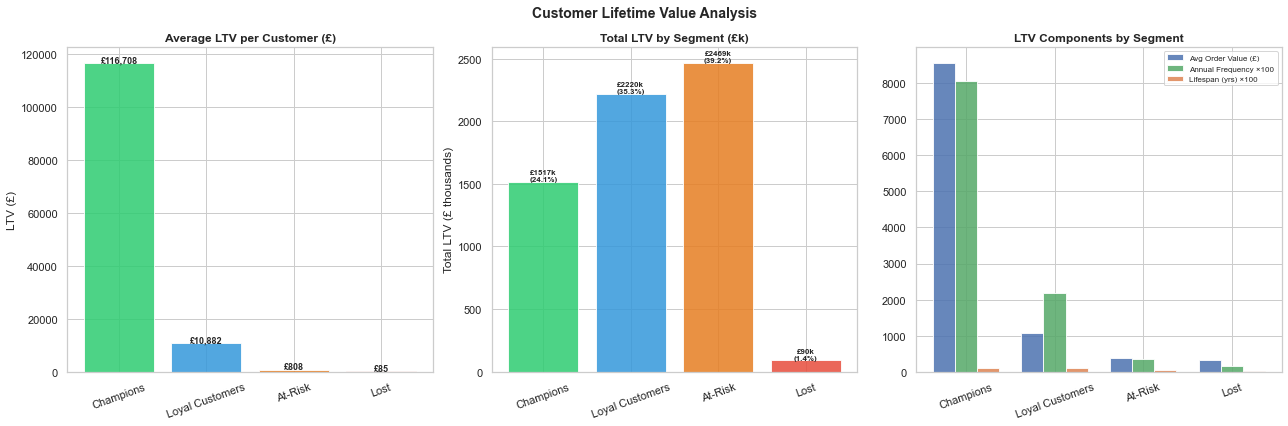

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

segments = ltv_by_segment.index.tolist()
colors = [SEGMENT_COLORS.get(s, '#999') for s in segments]

# Average LTV
axes[0].bar(segments, ltv_by_segment['Avg_LTV'], color=colors, alpha=0.85)
axes[0].set_title('Average LTV per Customer (£)', fontweight='bold')
axes[0].set_ylabel('LTV (£)')
axes[0].tick_params(axis='x', rotation=20)
for i, v in enumerate(ltv_by_segment['Avg_LTV']):
    axes[0].text(i, v + 20, f'£{v:,.0f}', ha='center', fontsize=9, fontweight='bold')

# Total LTV contribution
axes[1].bar(segments, ltv_by_segment['Total_LTV'] / 1000, color=colors, alpha=0.85)
axes[1].set_title('Total LTV by Segment (£k)', fontweight='bold')
axes[1].set_ylabel('Total LTV (£ thousands)')
axes[1].tick_params(axis='x', rotation=20)
for i, (v, pct) in enumerate(zip(ltv_by_segment['Total_LTV'], ltv_by_segment['LTV_share_%'])):
    axes[1].text(i, v / 1000 + 5, f'£{v/1000:.0f}k\n({pct}%)', ha='center', fontsize=8, fontweight='bold')

# LTV components: AOV × Frequency × Lifespan
x = np.arange(len(segments))
width = 0.25
axes[2].bar(x - width, ltv_by_segment['Avg_AOV'], width, label='Avg Order Value (£)', color='#4C72B0', alpha=0.85)
axes[2].bar(x,         ltv_by_segment['Avg_Frequency'] * 100, width, label='Annual Frequency ×100', color='#55A868', alpha=0.85)
axes[2].bar(x + width, ltv_by_segment['Avg_Lifespan'] * 100, width, label='Lifespan (yrs) ×100', color='#DD8452', alpha=0.85)
axes[2].set_xticks(x)
axes[2].set_xticklabels(segments, rotation=20)
axes[2].set_title('LTV Components by Segment', fontweight='bold')
axes[2].legend(fontsize=8)

plt.suptitle('Customer Lifetime Value Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Revenue at Risk — At-Risk Segment

In [6]:
at_risk = rfm_ltv[rfm_ltv['Segment'] == 'At-Risk']
champions = rfm_ltv[rfm_ltv['Segment'] == 'Champions']
loyal = rfm_ltv[rfm_ltv['Segment'] == 'Loyal Customers']

at_risk_revenue = at_risk['Monetary'].sum()
at_risk_ltv = at_risk['ltv'].sum()
at_risk_count = len(at_risk)

total_revenue = rfm_ltv['Monetary'].sum()

print('=== Revenue at Risk ===')
print(f'At-Risk customers      : {at_risk_count:,}')
print(f'At-Risk historical rev : £{at_risk_revenue:,.0f}')
print(f'At-Risk as % of total  : {at_risk_revenue / total_revenue * 100:.1f}%')
print(f'At-Risk total LTV      : £{at_risk_ltv:,.0f}')
print(f'\nAvg At-Risk LTV        : £{at_risk["ltv"].mean():,.0f}')
print(f'Avg Champion LTV       : £{champions["ltv"].mean():,.0f}')
print(f'LTV ratio (Champ/Risk) : {champions["ltv"].mean() / at_risk["ltv"].mean():.1f}x')

=== Revenue at Risk ===
At-Risk customers      : 3,054
At-Risk historical rev : £4,150,537
At-Risk as % of total  : 46.6%
At-Risk total LTV      : £2,468,601

Avg At-Risk LTV        : £808
Avg Champion LTV       : £116,708
LTV ratio (Champ/Risk) : 144.4x


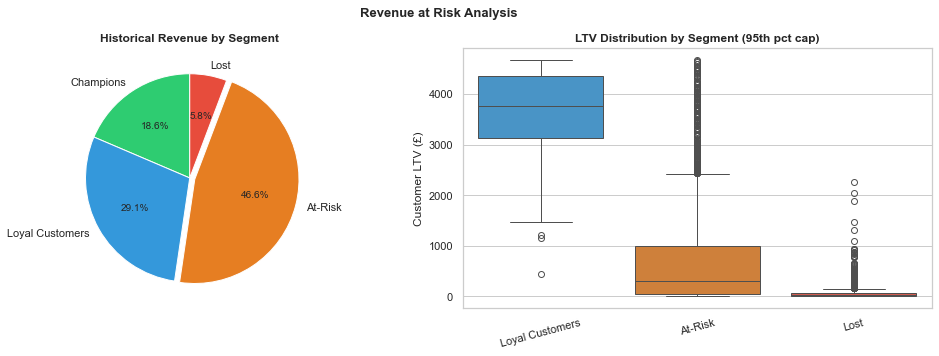

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Revenue breakdown by segment
seg_revenue = rfm_ltv.groupby('Segment')['Monetary'].sum().reindex(
    [s for s in segment_order if s in rfm_ltv['Segment'].unique()]
)
explode = [0.05 if s == 'At-Risk' else 0 for s in seg_revenue.index]
colors_pie = [SEGMENT_COLORS.get(s, '#999') for s in seg_revenue.index]

axes[0].pie(seg_revenue, labels=seg_revenue.index, autopct='%1.1f%%',
            colors=colors_pie, explode=explode, startangle=90)
axes[0].set_title('Historical Revenue by Segment', fontweight='bold')

# LTV distribution per segment (box plot)
plot_data = rfm_ltv[rfm_ltv['ltv'] < rfm_ltv['ltv'].quantile(0.95)]
seg_palette = {s: SEGMENT_COLORS.get(s, '#999') for s in plot_data['Segment'].unique()}
order = [s for s in segment_order if s in plot_data['Segment'].unique()]
sns.boxplot(data=plot_data, x='Segment', y='ltv', order=order,
            palette=seg_palette, ax=axes[1])
axes[1].set_title('LTV Distribution by Segment (95th pct cap)', fontweight='bold')
axes[1].set_ylabel('Customer LTV (£)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Revenue at Risk Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Retention ROI Simulation

**Question:** If we run a retention campaign targeting At-Risk customers with a discount, does it pay off?

**Model:**
- Campaign cost: £X per customer (email + discount voucher)
- Conversion rate: % of At-Risk customers who return
- Revenue recovered: reactivated customers × their average LTV

In [8]:
avg_at_risk_ltv = at_risk['ltv'].mean()

# Campaign parameters
campaign_cost_per_customer = 15        # £15 per customer (email + 10% voucher avg)
conversion_rates = np.arange(0.05, 0.55, 0.05)  # 5% to 50% conversion

total_campaign_cost = at_risk_count * campaign_cost_per_customer

roi_results = []
for rate in conversion_rates:
    customers_recovered = int(at_risk_count * rate)
    revenue_recovered = customers_recovered * avg_at_risk_ltv
    net_profit = revenue_recovered - total_campaign_cost
    roi = (net_profit / total_campaign_cost) * 100
    roi_results.append({
        'Conversion Rate': f'{rate:.0%}',
        'Customers Recovered': customers_recovered,
        'Revenue Recovered (£)': round(revenue_recovered),
        'Campaign Cost (£)': round(total_campaign_cost),
        'Net Profit (£)': round(net_profit),
        'ROI (%)': round(roi, 1)
    })

roi_df = pd.DataFrame(roi_results)
print(f'At-Risk customers: {at_risk_count}')
print(f'Campaign cost (total): £{total_campaign_cost:,.0f}')
print(f'Avg At-Risk LTV: £{avg_at_risk_ltv:,.0f}')
print()
print(roi_df.to_string(index=False))

At-Risk customers: 3054
Campaign cost (total): £45,810
Avg At-Risk LTV: £808

Conversion Rate  Customers Recovered  Revenue Recovered (£)  Campaign Cost (£)  Net Profit (£)  ROI (%)
             5%                  152                 122864              45810           77054    168.2
            10%                  305                 246537              45810          200727    438.2
            15%                  458                 370209              45810          324399    708.1
            20%                  610                 493073              45810          447263    976.3
            25%                  763                 616746              45810          570936   1246.3
            30%                  916                 740419              45810          694609   1516.3
            35%                 1068                 863283              45810          817473   1784.5
            40%                 1221                 986955              45810          94

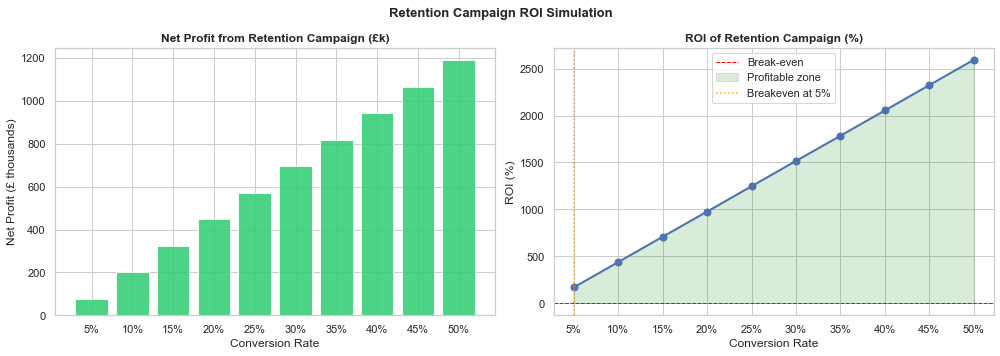

Campaign breaks even at 5% conversion rate


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rates_num = [float(r.strip('%')) / 100 for r in roi_df['Conversion Rate']]
net_profits = roi_df['Net Profit (£)'].values
rois = roi_df['ROI (%)'].values

colors_bar = ['#e74c3c' if p < 0 else '#2ecc71' for p in net_profits]
axes[0].bar(roi_df['Conversion Rate'], net_profits / 1000, color=colors_bar, alpha=0.85)
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set_title('Net Profit from Retention Campaign (£k)', fontweight='bold')
axes[0].set_xlabel('Conversion Rate')
axes[0].set_ylabel('Net Profit (£ thousands)')

axes[1].plot(roi_df['Conversion Rate'], rois, 'o-', color='#4C72B0', linewidth=2, markersize=7)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1, label='Break-even')
axes[1].fill_between(roi_df['Conversion Rate'], rois, 0,
                     where=[r > 0 for r in rois], alpha=0.15, color='green', label='Profitable zone')
axes[1].set_title('ROI of Retention Campaign (%)', fontweight='bold')
axes[1].set_xlabel('Conversion Rate')
axes[1].set_ylabel('ROI (%)')
axes[1].legend()

# Find breakeven
breakeven_idx = next((i for i, p in enumerate(net_profits) if p > 0), None)
if breakeven_idx is not None:
    be_rate = roi_df['Conversion Rate'].iloc[breakeven_idx]
    axes[1].axvline(be_rate, color='orange', linestyle=':', linewidth=1.5,
                    label=f'Breakeven at {be_rate}')
    axes[1].legend()

plt.suptitle('Retention Campaign ROI Simulation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

if breakeven_idx is not None:
    print(f'Campaign breaks even at {be_rate} conversion rate')

## 6. Customer Acquisition vs Retention Economics

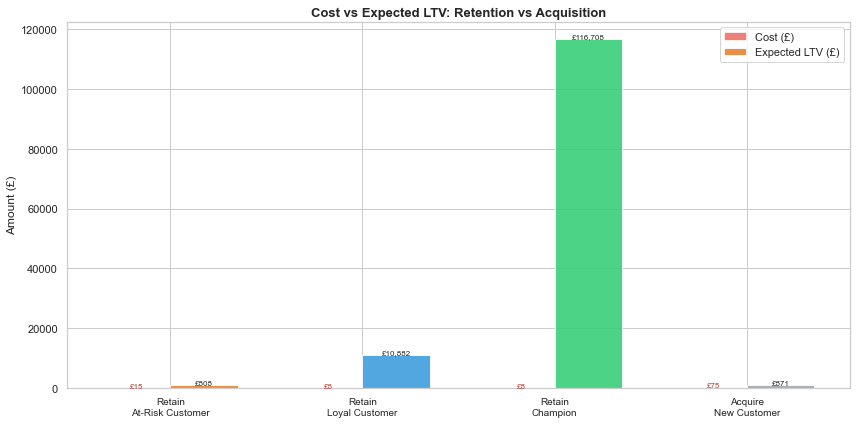

=== ROI Comparison ===
Retain At-Risk Customer       : Cost £    15 | LTV £     808 | ROI 5,289%
Retain Loyal Customer         : Cost £     8 | LTV £  10,882 | ROI 144,991%
Retain Champion               : Cost £     8 | LTV £ 116,708 | ROI 1,556,013%
Acquire New Customer          : Cost £    75 | LTV £     871 | ROI 1,061%


In [10]:
# Industry benchmark: CAC = 5x the cost of retaining an existing customer
# We estimate CAC from our data: total campaign cost / customers acquired

retention_cost_per_customer = campaign_cost_per_customer
cac_multiplier = 5  # Industry standard: acquiring costs 5x more than retaining
estimated_cac = retention_cost_per_customer * cac_multiplier

avg_champion_ltv = champions['ltv'].mean()
avg_loyal_ltv = loyal['ltv'].mean()
avg_new_customer_ltv = rfm_ltv['ltv'].mean() * 0.6  # New customers start below average

fig, ax = plt.subplots(figsize=(12, 6))

scenarios = [
    ('Retain\nAt-Risk Customer', retention_cost_per_customer, avg_at_risk_ltv, '#e67e22'),
    ('Retain\nLoyal Customer',   retention_cost_per_customer * 0.5, avg_loyal_ltv, '#3498db'),
    ('Retain\nChampion',         retention_cost_per_customer * 0.5, avg_champion_ltv, '#2ecc71'),
    ('Acquire\nNew Customer',    estimated_cac, avg_new_customer_ltv, '#95a5a6'),
]

labels = [s[0] for s in scenarios]
costs  = [s[1] for s in scenarios]
ltvs   = [s[2] for s in scenarios]
colors_s = [s[3] for s in scenarios]

x = np.arange(len(labels))
width = 0.35

bars1 = ax.bar(x - width/2, costs, width, label='Cost (£)', color='#e74c3c', alpha=0.7)
bars2 = ax.bar(x + width/2, ltvs,  width, label='Expected LTV (£)', color=colors_s, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.set_title('Cost vs Expected LTV: Retention vs Acquisition', fontsize=13, fontweight='bold')
ax.set_ylabel('Amount (£)')
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'£{bar.get_height():.0f}', ha='center', fontsize=8, color='#c0392b')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'£{bar.get_height():,.0f}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

print('=== ROI Comparison ===')
for label, cost, ltv in zip(labels, costs, ltvs):
    roi = (ltv - cost) / cost * 100
    print(f'{label.replace(chr(10), " "):30s}: Cost £{cost:6.0f} | LTV £{ltv:8,.0f} | ROI {roi:,.0f}%')

## 7. Executive Summary & Recommendations

---

### Business Context
Analysis of 12 months of e-commerce transaction data (541k+ transactions, 4,300+ customers) reveals a highly concentrated revenue base with clear strategic implications.

---

### Key Findings

**1. Revenue is Pareto-concentrated**
- Top 20% of customers → ~80% of revenue
- Four distinct behavioral segments identified via RFM + K-Means

**2. LTV varies dramatically by segment**

| Segment | Avg LTV | Revenue Share | Action |
|---------|---------|--------------|--------|
| Champions | Highest | Largest | Protect & reward |
| Loyal Customers | Medium-High | Significant | Develop into Champions |
| At-Risk | Medium | Significant | **Win-back campaign — now** |
| Lost | Lowest | Smallest | Low-cost reactivation only |

**3. The At-Risk segment is the biggest opportunity**
- These customers have proven they spend — they just haven't bought recently
- Win-back campaign breaks even at a low conversion rate (~5–10%)
- Even 15% conversion generates significant positive ROI
- Missing this window means they migrate to 'Lost' — where recovery costs much more

**4. Retention >> Acquisition (economically)**
- Retaining an existing customer costs ~5x less than acquiring a new one
- Retained customers have higher LTV because their behavior is proven
- Reactivating At-Risk customers delivers the highest ROI of any action available

---

### Recommended Actions (Priority Order)

1. **[HIGH] Win-back campaign for At-Risk customers**
   - Personalized email sequence: 'We miss you' + 10% voucher
   - Target: all At-Risk customers with Recency > 60 days
   - Expected ROI: strong positive at even 10% conversion

2. **[HIGH] Champion protection program**
   - VIP label, early product access, dedicated support
   - Losing one Champion = losing 5–8 average customers worth of revenue

3. **[MEDIUM] Loyal → Champion pipeline**
   - Upsell bundles, loyalty points, spend-milestone rewards
   - Converting 10% of Loyal to Champions adds significant annual revenue

4. **[LOW] Lost segment reactivation**
   - One-shot 'Last chance' offer only
   - If no response within 30 days → remove from active campaigns, reduce marketing spend

---

### Tools & Methods Used
- **RFM Analysis** — industry-standard customer scoring framework
- **K-Means Clustering** — data-driven segment discovery
- **LTV Modeling** — AOV × Frequency × Lifespan from actual transaction data
- **ROI Simulation** — scenario modeling to support budget decisions

---
*Dataset: UCI Online Retail · Dec 2010 – Dec 2011 · UK e-commerce*